# Bài tập Buổi 7 — Phân loại 1: Hồi quy Logistic & KNN

**Sinh viên thực hiện:** Phú Thành · Khóa hè 2026 — Python & Machine Learning · ML IoT Lab

---

Notebook gồm 2 bài:

- **Bài 1 — Titanic:** dùng **Logistic Regression** dự đoán sống sót, so sánh với **Linear Regression** (dùng làm bộ phân loại) qua Accuracy / Precision / Recall / F1 / Confusion Matrix.
- **Bài 2 — Dry Bean:** phân loại 7 loại hạt bằng **Logistic Regression** và **KNN**, so sánh hai mô hình.


## 0. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Sẵn sàng.")

Sẵn sàng.


---
# Bài 1 — Titanic: Logistic Regression vs Linear Regression

Ta tái sử dụng bộ **Titanic** và cách tiền xử lý đã làm ở Buổi 5 (loại cột rò rỉ nhãn, điền missing, encode/scale trong pipeline fit chỉ trên train), sau đó huấn luyện **Logistic Regression** và so sánh với **Linear Regression**.


### 1.1. Tải dữ liệu và loại cột rò rỉ nhãn (giống Buổi 5)

In [2]:
try:
    tdf = sns.load_dataset("titanic")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    tdf = pd.read_csv(url); tdf.columns = [c.lower() for c in tdf.columns]

# Bỏ cột rò rỉ nhãn / dư thừa, giữ lại đúng 8 cột như Buổi 5
leaky = ["alive", "who", "adult_male", "class", "deck", "embark_town", "alone"]
tdf = tdf.drop(columns=[c for c in leaky if c in tdf.columns])
print("Các cột giữ lại:", list(tdf.columns))
tdf.head()

Các cột giữ lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 1.2. Chia train/test và xây pipeline tiền xử lý (fit chỉ trên train)

Chia **80/20** có `stratify` để giữ tỷ lệ 2 lớp. Pipeline: điền median + `RobustScaler` cho biến số; điền mode + one-hot cho biến phân loại; `pclass` giữ nguyên. Tất cả `fit` **chỉ trên train** để chống data leakage.

In [3]:
X = tdf.drop(columns=["survived"])
y = tdf["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

pipe_num = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler",  RobustScaler())])
pipe_cat = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("onehot",  OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([
    ("num", pipe_num, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols)])

preprocess.fit(X_train)
X_train_t = preprocess.transform(X_train)
X_test_t  = preprocess.transform(X_test)
print("Train:", X_train_t.shape, "| Test:", X_test_t.shape)
print("Tỷ lệ sống sót - train: %.3f | test: %.3f" % (y_train.mean(), y_test.mean()))

Train: (712, 10) | Test: (179, 10)
Tỷ lệ sống sót - train: 0.383 | test: 0.385


### 1.3. Huấn luyện Logistic Regression

In [4]:
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_t, y_train)
y_pred_logit = logit.predict(X_test_t)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_logit,
      target_names=["Không sống (0)", "Sống sót (1)"]))

=== Logistic Regression ===
                precision    recall  f1-score   support

Không sống (0)       0.81      0.89      0.85       110
  Sống sót (1)       0.79      0.67      0.72        69

      accuracy                           0.80       179
     macro avg       0.80      0.78      0.79       179
  weighted avg       0.80      0.80      0.80       179



### 1.4. Huấn luyện Linear Regression làm bộ phân loại

`LinearRegression` vốn dùng cho hồi quy (đầu ra liên tục). Để dùng cho phân loại nhị phân, ta dự đoán giá trị liên tục rồi **cắt ngưỡng 0.5**: `>= 0.5 → 1`, ngược lại `→ 0`. Đây chính là cách để thấy vì sao Linear Regression **không phù hợp** cho bài toán phân loại.

In [5]:
linreg = LinearRegression()
linreg.fit(X_train_t, y_train)
y_score_lin = linreg.predict(X_test_t)          # giá trị liên tục
y_pred_lin = (y_score_lin >= 0.5).astype(int)   # cắt ngưỡng 0.5

print("Khoảng giá trị dự đoán liên tục của Linear Regression: [%.2f, %.2f]"
      % (y_score_lin.min(), y_score_lin.max()))
print("(Chú ý: có giá trị < 0 hoặc > 1 — không phải xác suất hợp lệ)\n")
print("=== Linear Regression (cắt ngưỡng 0.5) ===")
print(classification_report(y_test, y_pred_lin,
      target_names=["Không sống (0)", "Sống sót (1)"]))

Khoảng giá trị dự đoán liên tục của Linear Regression: [-0.20, 1.07]
(Chú ý: có giá trị < 0 hoặc > 1 — không phải xác suất hợp lệ)

=== Linear Regression (cắt ngưỡng 0.5) ===
                precision    recall  f1-score   support

Không sống (0)       0.82      0.88      0.85       110
  Sống sót (1)       0.79      0.70      0.74        69

      accuracy                           0.81       179
     macro avg       0.80      0.79      0.79       179
  weighted avg       0.81      0.81      0.81       179



### 1.5. So sánh hai mô hình

,Logistic Regression,Linear Regression
Accuracy,0.8045,0.8101
Precision,0.7931,0.7869
Recall,0.6667,0.6957
F1,0.7244,0.7385


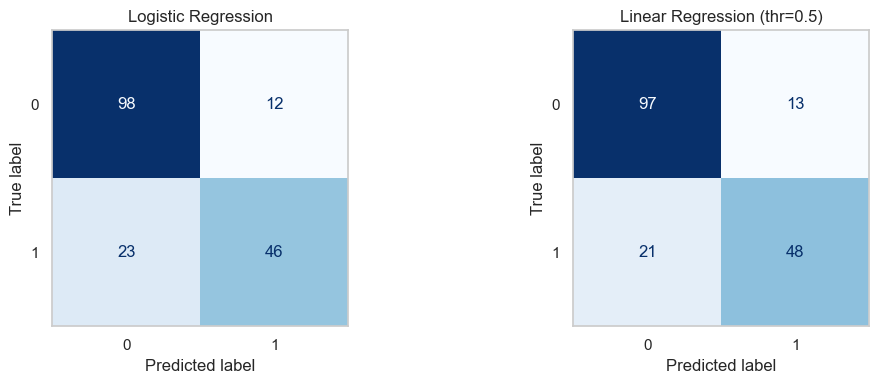

In [6]:
def scores(y_true, y_pred):
    return {"Accuracy":  accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred),
            "Recall":    recall_score(y_true, y_pred),
            "F1":        f1_score(y_true, y_pred)}

cmp = pd.DataFrame({"Logistic Regression": scores(y_test, y_pred_logit),
                    "Linear Regression":   scores(y_test, y_pred_lin)}).round(4)
display(cmp)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, yp, name in zip(axes, [y_pred_logit, y_pred_lin],
                        ["Logistic Regression", "Linear Regression (thr=0.5)"]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, yp),
                           display_labels=["0", "1"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name); ax.grid(False)
plt.tight_layout(); plt.show()

**Nhận xét Bài 1:**

- Trên tập test, **hai mô hình cho kết quả gần như ngang nhau** (Accuracy: Logistic ≈ 0.80, Linear ≈ 0.81; F1 lớp sống sót ≈ 0.72–0.74). Thực tế Linear còn nhỉnh hơn Logistic một chút xíu ở lần chạy này. Điều này hợp lý vì ranh giới của Titanic khá gần tuyến tính. **Nhưng con số ngang nhau KHÔNG có nghĩa Linear Regression phù hợp** — đó chỉ là sự trùng hợp trên bộ dữ liệu dễ này.
- **Linear Regression về bản chất sai mô hình cho phân loại:** đầu ra là giá trị liên tục, thực tế đã cho ra khoảng **[-0.20, 1.07]** (xem output) — tức có giá trị **< 0 và > 1**, **không thể diễn giải thành xác suất**. Kết quả phụ thuộc mạnh vào ngưỡng cắt tùy chọn và rất nhạy cảm với outlier. Ngược lại, **Logistic Regression** dùng hàm **sigmoid** ép đầu ra về [0, 1] (xác suất hợp lệ) và tối ưu theo **log-loss** đúng cho bài toán phân loại.
- Với bài toán "sống sót" mất cân bằng nhẹ (~62/38), nên nhìn **Recall/F1 của lớp sống sót** hơn là chỉ Accuracy. **Kết luận:** dù điểm số xấp xỉ nhau, **Logistic Regression mới là lựa chọn đúng đắn** cho bài toán phân loại nhị phân vì nó đúng về mặt xác suất và tổng quát hóa tốt hơn trên các bộ dữ liệu khó; Linear Regression chỉ nên dùng cho bài toán hồi quy (dự đoán giá trị liên tục) như bài Housing ở Buổi 6.

---
# Bài 2 — Dry Bean: Logistic Regression & KNN

Phân loại **7 loại hạt đậu** (BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER, SIRA) dựa trên 16 đặc trưng hình học. Dữ liệu đã được tiền xử lý & chia 80/20 (stratify) ở `processing_seeds.ipynb`.


### 2.1. Nạp dữ liệu train/test (tự sinh từ xlsx nếu chưa có CSV)

In [7]:
DATA_DIR = Path("Dry_Bean_Dataset")
TRAIN_CSV = DATA_DIR / "dry_bean_train.csv"
TEST_CSV  = DATA_DIR / "dry_bean_test.csv"

def build_split_from_xlsx():
    """Tái tạo split 80/20 (stratify) từ file gốc .xlsx nếu chưa có CSV."""
    df = pd.read_excel(DATA_DIR / "Dry_Bean_Dataset.xlsx", engine="openpyxl")
    df.columns = (df.columns.str.strip().str.lower()
                    .str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_"))
    num = [c for c in df.columns if c != "class"]
    df[num] = df[num].apply(pd.to_numeric, errors="coerce")
    df["class"] = df["class"].astype(str).str.strip().str.upper()
    df = df.dropna().drop_duplicates().reset_index(drop=True)
    tr, te = train_test_split(df, test_size=0.2, random_state=42, stratify=df["class"])
    tr.reset_index(drop=True).to_csv(TRAIN_CSV, index=False)
    te.reset_index(drop=True).to_csv(TEST_CSV, index=False)

if not (TRAIN_CSV.exists() and TEST_CSV.exists()):
    print("Chưa có CSV -> sinh lại từ Dry_Bean_Dataset.xlsx ...")
    build_split_from_xlsx()

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
print("Train:", train_df.shape, "| Test:", test_df.shape)
train_df.head()

Train: (10834, 17) | Test: (2709, 17)


,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004,CALI
1,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384,BARBUNYA
2,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906,HOROZ
3,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611,SIRA
4,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318,CALI


### 2.2. Tách feature/target và scaling (fit chỉ trên train)

In [8]:
target = "class"
feat = [c for c in train_df.columns if c != target]

X_train2, y_train2 = train_df[feat], train_df[target]
X_test2,  y_test2  = test_df[feat],  test_df[target]

# Scaling BẮT BUỘC cho KNN (dựa trên khoảng cách) và tốt cho Logistic
scaler2 = StandardScaler()
X_train2_s = scaler2.fit_transform(X_train2)   # fit chỉ trên train
X_test2_s  = scaler2.transform(X_test2)

print("Số feature:", len(feat))
print("Phân bố lớp (train):")
print(y_train2.value_counts().sort_index())

Số feature: 16
Phân bố lớp (train):
class
BARBUNYA    1057
BOMBAY       418
CALI        1304
DERMASON    2837
HOROZ       1488
SEKER       1621
SIRA        2109
Name: count, dtype: int64


### 2.3. Logistic Regression (đa lớp)

In [9]:
logit2 = LogisticRegression(max_iter=2000)   # softmax đa lớp
logit2.fit(X_train2_s, y_train2)
y_pred_logit2 = logit2.predict(X_test2_s)

acc_logit = accuracy_score(y_test2, y_pred_logit2)
print("Logistic Regression - Accuracy: %.4f\n" % acc_logit)
print(classification_report(y_test2, y_pred_logit2))

Logistic Regression - Accuracy: 0.9192

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



### 2.4. K-Nearest Neighbors (chọn k qua thử nghiệm)

In [10]:
ks = [3, 5, 7, 9, 11, 15]
acc_by_k = {}
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train2_s, y_train2)
    acc_by_k[k] = accuracy_score(y_test2, knn.predict(X_test2_s))
print("Accuracy theo k:", {k: round(v, 4) for k, v in acc_by_k.items()})

best_k = max(acc_by_k, key=acc_by_k.get)
print("k tốt nhất:", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train2_s, y_train2)
y_pred_knn = knn.predict(X_test2_s)
acc_knn = accuracy_score(y_test2, y_pred_knn)
print("\nKNN (k=%d) - Accuracy: %.4f\n" % (best_k, acc_knn))
print(classification_report(y_test2, y_pred_knn))

Accuracy theo k: {3: 0.911, 5: 0.9155, 7: 0.9118, 9: 0.9129, 11: 0.9144, 15: 0.9158}
k tốt nhất: 15

KNN (k=15) - Accuracy: 0.9158



              precision    recall  f1-score   support

    BARBUNYA       0.96      0.88      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.96      0.93       326
    DERMASON       0.91      0.90      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



### 2.5. So sánh Logistic vs KNN + Confusion Matrix

So sánh Accuracy:  Logistic = 0.9192 | KNN(k=15) = 0.9158


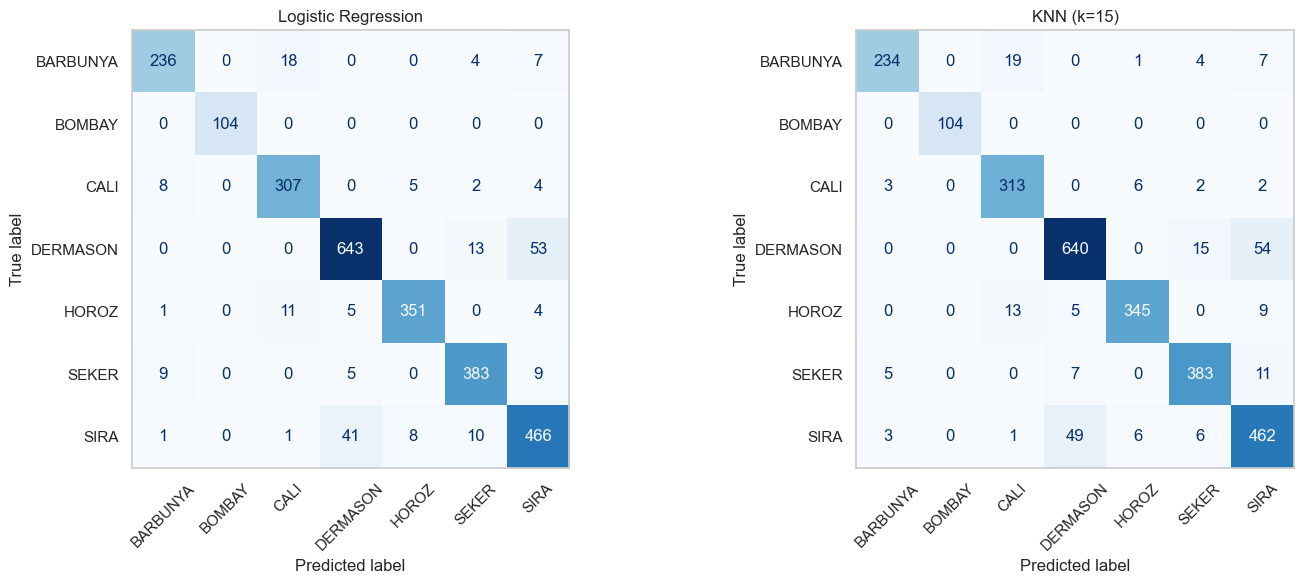

In [11]:
print("So sánh Accuracy:  Logistic = %.4f | KNN(k=%d) = %.4f"
      % (acc_logit, best_k, acc_knn))

labels = sorted(y_test2.unique())
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, yp, name in zip(axes, [y_pred_logit2, y_pred_knn],
                        ["Logistic Regression", f"KNN (k={best_k})"]):
    ConfusionMatrixDisplay(confusion_matrix(y_test2, yp, labels=labels),
                           display_labels=labels).plot(ax=ax, cmap="Blues",
                           colorbar=False, xticks_rotation=45)
    ax.set_title(name); ax.grid(False)
plt.tight_layout(); plt.show()

**Nhận xét Bài 2:**

- Cả **Logistic Regression** và **KNN** đều phân loại 7 loại hạt tốt (accuracy ~0.9+) nhờ các đặc trưng hình học tách lớp rõ. `BOMBAY` (hạt to bất thường) gần như được phân loại hoàn hảo; nhầm lẫn chủ yếu xảy ra giữa các cặp lớp có hình dạng tương tự như **SIRA ↔ DERMASON** và **CALI ↔ BARBUNYA** (nhìn các ô ngoài đường chéo của confusion matrix).
- **Scaling là bắt buộc với KNN**: KNN dựa trên khoảng cách Euclid nên nếu không chuẩn hóa, các đặc trưng thang đo lớn (`area`, `convexarea` ~ hàng chục nghìn) sẽ lấn át hoàn toàn các đặc trưng nhỏ (`shapefactor` ~ 0.00x).
- **Khác biệt bản chất:** Logistic Regression là mô hình **tham số** (học ranh giới tuyến tính, huấn luyện chậm nhưng dự đoán nhanh, dễ diễn giải qua hệ số). KNN **phi tham số, lazy** (không "học", lưu toàn bộ train và tính khoảng cách khi dự đoán → dự đoán chậm trên tập lớn, nhạy với k và với đặc trưng nhiễu). Với bộ dữ liệu này cả hai đều phù hợp; nếu cần tốc độ dự đoán và khả năng giải thích thì ưu tiên Logistic.
